In [1]:
%load_ext autoreload
%autoreload 2

# import sys, os
# sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'bilateral-m1-pcca', 'tools'))
# # Simpler if you run the notebook from the repo root:
# sys.path.insert(0, 'tools')


In [2]:
import scipy.io
import numpy as np
from tools.load_session import inspect_session, load_session
from tools.trial_epoching import get_session_trial_start_frames, get_session_touch_onset_frames, get_trial_outcome, compute_derived    
from tools.plotting_fncs import plot_trial_variable, plot_session_metrics
from tools.input_data_generation import get_neuron_mask, build_spike_count_matrices, prepare_session_for_pcca
from tools.run_save_model import fit_session_pcca, extract_session_metrics, save_session_results#, run_or_load_session
from tools.load_session import TIME_STEP
import matplotlib.pyplot as plt
%matplotlib widget


In [11]:
# inspect_session('data/P2.mat')

In [3]:
session_id='P2'
session_data = load_session(f'data/{session_id}.mat')
derived = compute_derived(session_data)

## U7, U8 problem
## U1 only has 17 neurons in LH




In [4]:
### Stimulus and outcome information

print(f' All Unique stimuli: {set(derived["trial_stimulus"])}')
print(f' Rewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["hit", "miss"]])}')
print(f' Unrewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["false_alarm", "correct_rej"]])}')
print()
print(f' Trial stimulus counts:')
for stim in set(derived["trial_stimulus"]):
    print(f'  {stim}: {derived["trial_stimulus"].count(stim)}')
print()
print('Trial outcome counts:')
print(f' Total hit trials: {sum([1 for o in derived["trial_outcome"] if o == "hit"])}')
print(f' Total miss trials: {sum([1 for o in derived["trial_outcome"] if o == "miss"])}')
print(f' Total false alarm trials: {sum([1 for o in derived["trial_outcome"] if o == "false_alarm"])}')
print(f' Total correct rejection trials: {sum([1 for o in derived["trial_outcome"] if o == "correct_rej"])}')

 All Unique stimuli: {'rightC+leftD', 'rightD', 'rightD+leftC', 'rightC', 'rightD+leftD', 'leftD', 'rightC+leftC', 'none', 'leftC'}
 Rewarded stimuli: {'rightC+leftC', 'rightD+leftD'}
 Unrewarded stimuli: {'rightC+leftD', 'rightD', 'rightD+leftC', 'rightC', 'leftD', 'none', 'leftC'}

 Trial stimulus counts:
  rightC+leftD: 124
  rightD: 29
  rightD+leftC: 96
  rightC: 44
  rightD+leftD: 122
  leftD: 33
  rightC+leftC: 122
  none: 21
  leftC: 43

Trial outcome counts:
 Total hit trials: 196
 Total miss trials: 48
 Total false alarm trials: 8
 Total correct rejection trials: 382


In [5]:
### Neuronal data information

print(f'LH neurons: {session_data["n_lh"]}, RH neurons: {session_data["n_rh"]}, Total neurons: {session_data["n_lh"] + session_data["n_rh"]}')

rs = np.sum(session_data['fsrs'] == 1)
fs = np.sum(session_data['fsrs'] == -1)
un = np.sum(session_data['fsrs'] == 0)

print(f"RS: {rs}, FS: {fs}, UN: {un}")

for hemi, mask in [('LH', session_data['loc_lh_mask']), ('RH', session_data['loc_rh_mask'])]:
    fsrs = session_data['fsrs'][mask]
    print(f"{hemi}  RS: {(fsrs==1).sum()}  FS: {(fsrs==-1).sum()}  UN: {(fsrs==0).sum()}")


LH neurons: 110, RH neurons: 129, Total neurons: 239
RS: 229, FS: 3, UN: 7
LH  RS: 109  FS: 0  UN: 1
RH  RS: 120  FS: 3  UN: 6


Hit trials : 196
Touch latency — mean: 0.644 s  median: 0.642 s
Lick latency  — mean: 1.729 s  median: 1.793 s


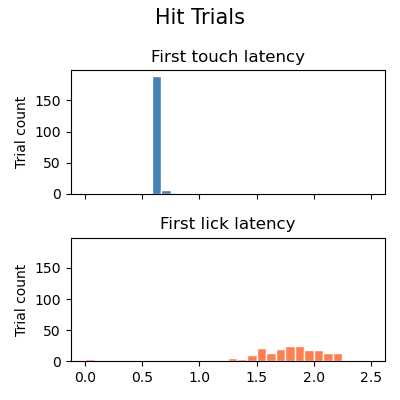

In [6]:

# ── Reference point: swap between trial start and stimulus onset ──────────
reference_frames = derived['trial_start_frames']   # trial start
# reference_frames = derived['trial_start_frames'] + 0.5        # stimulus onset

# ── Hit trials only ───────────────────────────────────────────────────────
hit_mask = np.array([o == 'hit' for o in derived['trial_outcome']])
# ── Latencies (seconds) ───────────────────────────────────────────────────
touch_latency_s = (derived['touch_onset_frames'][hit_mask] - reference_frames[hit_mask]) * TIME_STEP
lick_latency_s  = (derived['trial_first_lick_frames'][hit_mask]  - reference_frames[hit_mask]) * TIME_STEP

print(f"Hit trials : {hit_mask.sum()}")
print(f"Touch latency — mean: {np.nanmean(touch_latency_s):.3f} s  median: {np.nanmedian(touch_latency_s):.3f} s")
print(f"Lick latency  — mean: {np.nanmean(lick_latency_s):.3f} s  median: {np.nanmedian(lick_latency_s):.3f} s")

bins = np.linspace(0, 2.5, 31)  # 30 bins between 0 and 2.5

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharey=True, sharex=True)

axes[0].hist(touch_latency_s[~np.isnan(touch_latency_s)], bins=bins, color='steelblue', edgecolor='white')
axes[0].set_ylabel('Trial count')
axes[0].set_title('First touch latency')

axes[1].hist(lick_latency_s[~np.isnan(lick_latency_s)], bins=bins, color='coral', edgecolor='white')
axes[1].set_ylabel('Trial count')
axes[1].set_title('First lick latency')

plt.suptitle('Hit Trials', fontsize=15)
plt.tight_layout()
plt.show()



In [ ]:
# # Inspect a single trial

# trial_idx=99

# valid_vars = ['piston_frames', 'touch_frames', 'licks',
#             #   'whisker_angle', 'curvature','phase', 'run_speed', 
#               'hits', 'misses', 'false_alarms','correct_rejs', 
#               ]
# for var_name in valid_vars:
#     if var_name in ['hits', 'misses', 'false_alarms', 'correct_rejs', 'licks']:
#         plot_trial_variable(session_data, derived['trial_start_frames'], var_name=var_name, trial_idx=trial_idx, ylim=(-0.1, 1.1))
#     else:
#         plot_trial_variable(session_data, derived['trial_start_frames'], var_name=var_name, trial_idx=trial_idx)


In [9]:
# Include only trials with valid stimuli (i.e., not None)
stim_valid_mask = np.array([s is not 'none' for s in derived['trial_stimulus']])

# Include only trials with hit, miss, or correct rejection outcomes (exclude false alarms) (hit trials with lick latency > 1.0 s are also excluded)
hit_mask = np.array([o == 'hit' for o in derived['trial_outcome']])
miss_mask = np.array([o == 'miss' for o in derived['trial_outcome']])
correct_rej_mask = np.array([o == 'correct_rej' for o in derived['trial_outcome']])
false_alarm_mask = np.array([o == 'false_alarm' for o in derived['trial_outcome']])

hit_fast_lick_mask = hit_mask.copy()
hit_fast_lick_mask[hit_mask] = lick_latency_s > 1.0

combined_mask = (hit_fast_lick_mask | miss_mask | correct_rej_mask) & stim_valid_mask
filtered_trial_indices = np.where(combined_mask)[0]

print(f"Filtered trials: {len(filtered_trial_indices)}")

lh_neuron_mask = get_neuron_mask(session_data, hemisphere='LH', fsrs=[1, -1], min_rate_hz=5.0)
rh_neuron_mask = get_neuron_mask(session_data, hemisphere='RH', fsrs=[1, -1], min_rate_hz=5.0)

print(f"LH neurons: {lh_neuron_mask.sum()}, RH neurons: {rh_neuron_mask.sum()}")

Filtered trials: 595
LH neurons: 69, RH neurons: 64


<>:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/var/folders/__/cj7mp8_x5y1_sxsmfdv5pyv00000gn/T/ipykernel_30637/3756608596.py:2: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  stim_valid_mask = np.array([s is not 'none' for s in derived['trial_stimulus']])


In [9]:
windows = [(0.0, 1.0), (0.0, 0.5), (0.5, 1.0)]

for window in windows:
    win_label = f'{window[0]:.1f}-{window[1]:.1f}'
    sid = f'{session_id}_w{win_label}'
    print(f'\n=== Window {win_label} s ===')

    bundle = prepare_session_for_pcca(
        session_data   = session_data,
        derived        = derived,
        trial_indices  = filtered_trial_indices,
        window         = window,
        lh_neuron_mask = lh_neuron_mask,
        rh_neuron_mask = rh_neuron_mask,
    )

    model, cv_results = fit_session_pcca(bundle, d_max=6, n_folds=10, rand_seed=42)
    metrics, summary  = extract_session_metrics(model, session_id=sid)
    save_session_results(sid, model, cv_results, metrics, summary)
    fig = plot_session_metrics(metrics, summary, session_id=sid)


=== Window 0.0-1.0 s ===
Crossvalidating pCCA-FA model to choose # of dims...
   Fold  1  of  10 ...


  3%|▎         | 9/343 [00:03<02:04,  2.67it/s]


KeyboardInterrupt: 

In [14]:
from tools.run_save_model import load_session_results
model, cv_results, metrics, summary = load_session_results(session_id)

Loaded ← results/P2_w0.0-1.0.joblib  (d=6, d1=6, d2=6)


In [15]:
print("d =", model.params['d'])
print("d1 =", model.params['d1'], "  L_1 shape:", model.params['L_1'].shape)
print("d2 =", model.params['d2'], "  L_2 shape:", model.params['L_2'].shape)


d = 6
d1 = 6   L_1 shape: (69, 6)
d2 = 6   L_2 shape: (64, 6)


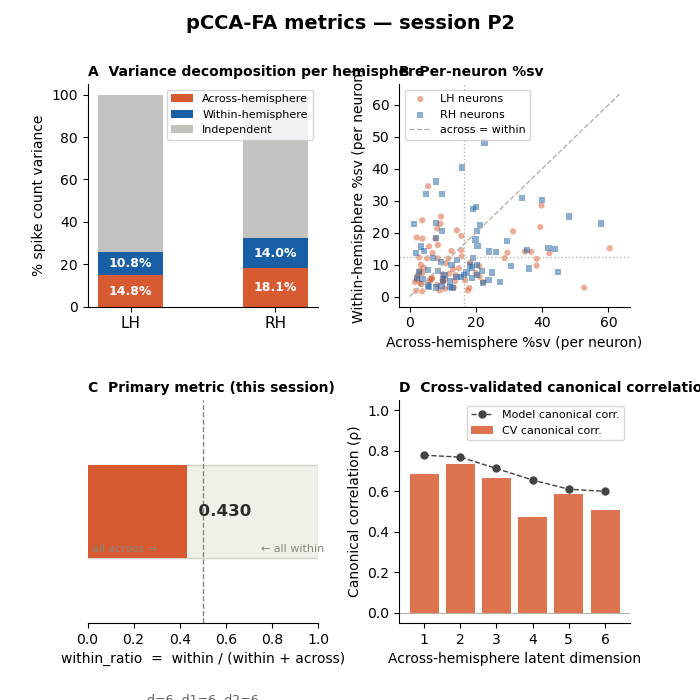

In [113]:
fig = plot_session_metrics(metrics, summary, session_id=session_id)

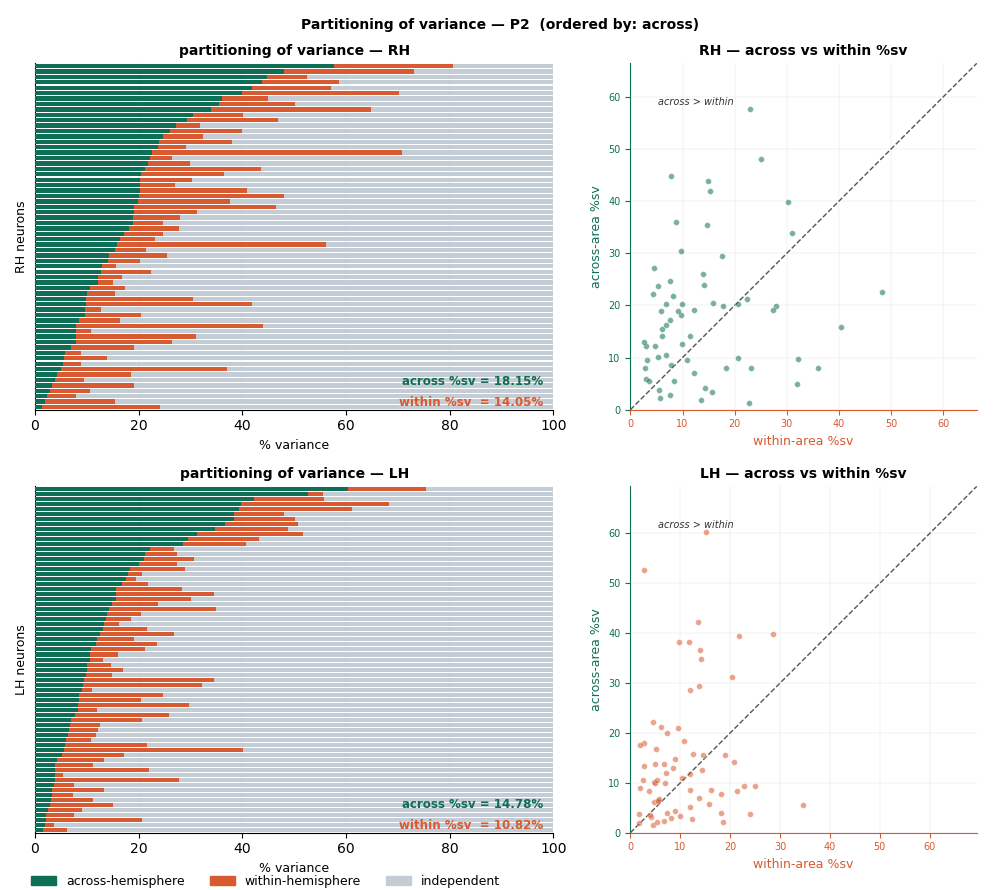

In [134]:
from tools.plotting_fncs import plot_psv_partitioning

fig = plot_psv_partitioning(metrics, session_id=session_id, order_by='across')
plt.show()

# save whenever you're ready
fig.savefig(f'figures/psv_{session_id}.png', bbox_inches='tight')

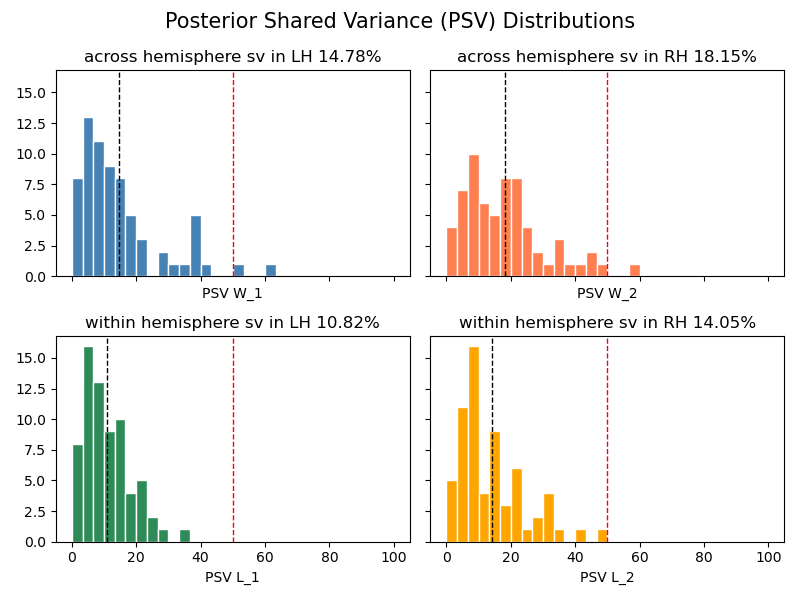

In [120]:

bins = np.linspace(0, 100, 31)  # 30 bins between 0 and 1.0
fig, axes = plt.subplots(2,2, figsize=(8, 6), sharex=True, sharey=True)
axes[0,0].hist(metrics['psv']['psv_W_1'], bins, color='steelblue', edgecolor='white')
axes[0,0].set_title(f'across hemisphere sv in LH {metrics["psv"]["avg_psv_W_1"]:.2f}%')
axes[0,0].axvline(np.mean(metrics['psv']['psv_W_1']), color='black', linestyle='dashed', linewidth=1)
axes[0,0].axvline(50, color='red', linestyle='dashed', linewidth=1)
axes[0,0].set_xlabel('PSV W_1')
axes[0,1].hist(metrics['psv']['psv_W_2'], bins, color='coral', edgecolor='white')
axes[0,1].set_title(f'across hemisphere sv in RH {metrics["psv"]["avg_psv_W_2"]:.2f}%')
axes[0,1].axvline(np.mean(metrics['psv']['psv_W_2']), color='black', linestyle='dashed', linewidth=1)
axes[0,1].axvline(50, color='red', linestyle='dashed', linewidth=1)
axes[0,1].set_xlabel('PSV W_2')
axes[1,0].hist(metrics['psv']['psv_L_1'], bins, color='seagreen', edgecolor='white')
axes[1,0].set_title(f'within hemisphere sv in LH {metrics["psv"]["avg_psv_L_1"]:.2f}%')
axes[1,0].axvline(np.mean(metrics['psv']['psv_L_1']), color='black', linestyle='dashed', linewidth=1)
axes[1,0].axvline(50, color='red', linestyle='dashed', linewidth=1)
axes[1,0].set_xlabel('PSV L_1')
axes[1,1].hist(metrics['psv']['psv_L_2'], bins, color='orange', edgecolor='white')
axes[1,1].set_title(f'within hemisphere sv in RH {metrics["psv"]["avg_psv_L_2"]:.2f}%')
axes[1,1].axvline(np.mean(metrics['psv']['psv_L_2']), color='black', linestyle='dashed', linewidth=1)
axes[1,1].axvline(50, color='red', linestyle='dashed', linewidth=1)
axes[1,1].set_xlabel('PSV L_2')
plt.suptitle('Posterior Shared Variance (PSV) Distributions', fontsize=15)
plt.tight_layout()


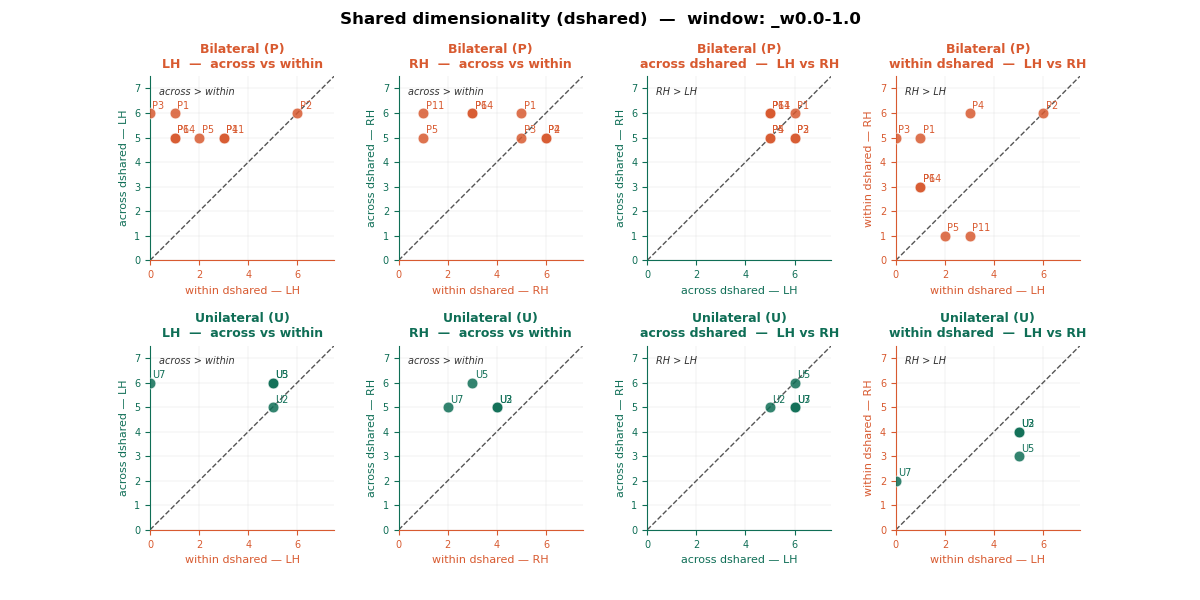

In [135]:
from tools.plotting_fncs import plot_dshared_scatter

fig = plot_dshared_scatter('_w0.0-1.0')
plt.show()
fig.savefig('figures/dshared.png', dpi=150, bbox_inches='tight')

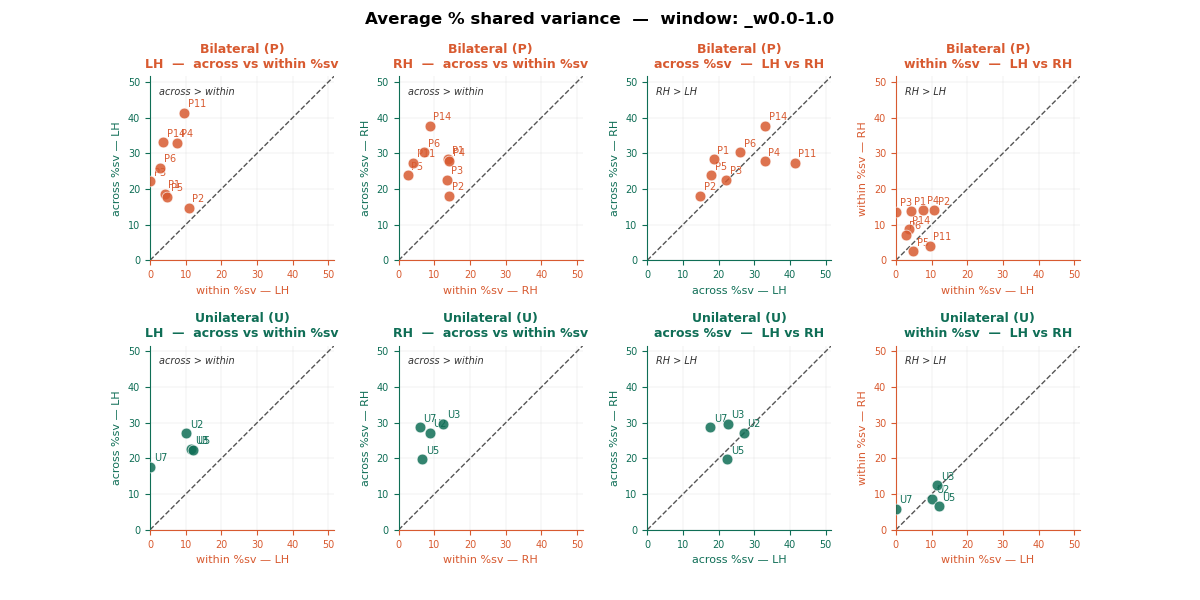

In [136]:
from tools.plotting_fncs import plot_psv_scatter

fig = plot_psv_scatter('_w0.0-1.0')
plt.show()
fig.savefig('figures/psv_scatter_w0.0-1.0.png', dpi=150, bbox_inches='tight')

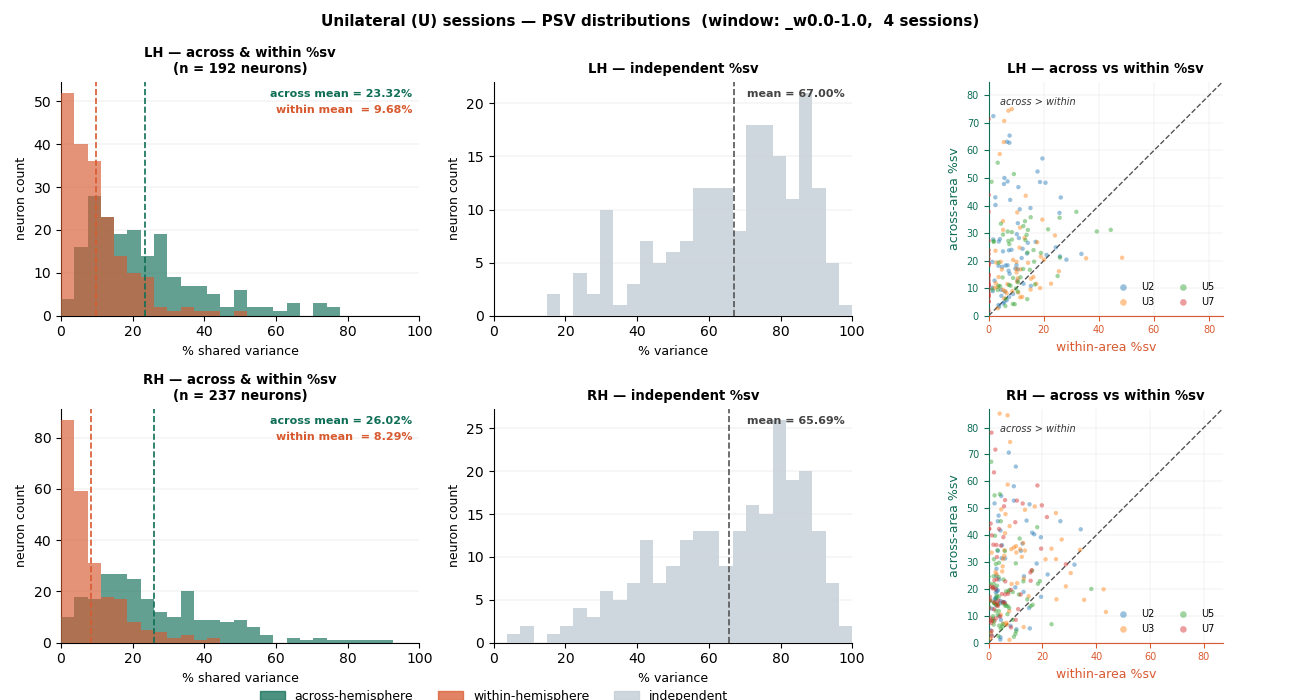

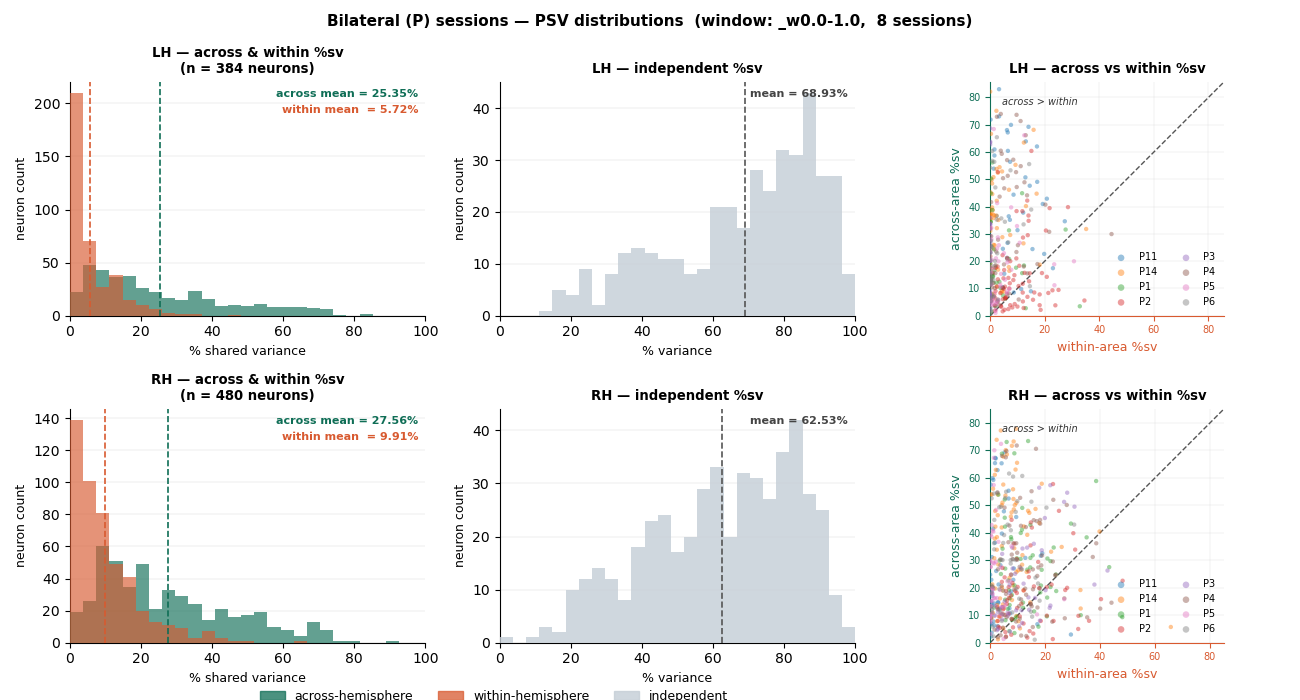

In [137]:
from tools.plotting_fncs import plot_psv_pooled

fig_P, fig_U = plot_psv_pooled('_w0.0-1.0')

fig_P.savefig('figures/psv_pooled_bilateral.png',  dpi=150, bbox_inches='tight')
fig_U.savefig('figures/psv_pooled_unilateral.png', dpi=150, bbox_inches='tight')
plt.show()

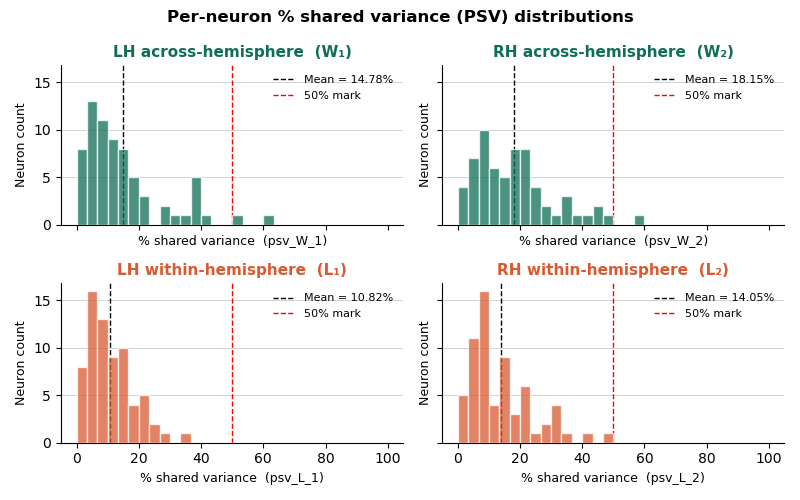

In [87]:
teal  = '#0F6E56'   # across-hemisphere (W)
coral = '#D85A30'   # within-hemisphere (L)

bins = np.linspace(0, 100, 31)  # 30 bins between 0 and 100%

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True, sharey=True)

panels = [
    (axes[0, 0], metrics['psv']['psv_W_1'], metrics['psv']['avg_psv_W_1'],
     'LH across-hemisphere  (W₁)', 'psv_W_1', teal),
    (axes[0, 1], metrics['psv']['psv_W_2'], metrics['psv']['avg_psv_W_2'],
     'RH across-hemisphere  (W₂)', 'psv_W_2', teal),
    (axes[1, 0], metrics['psv']['psv_L_1'], metrics['psv']['avg_psv_L_1'],
     'LH within-hemisphere  (L₁)', 'psv_L_1', coral),
    (axes[1, 1], metrics['psv']['psv_L_2'], metrics['psv']['avg_psv_L_2'],
     'RH within-hemisphere  (L₂)', 'psv_L_2', coral),
]

for ax, vals, avg, title, xlabel, color in panels:
    ax.hist(vals, bins, color=color, alpha=0.75, edgecolor='white', zorder=3)
    ax.axvline(avg, color='black', linestyle='dashed', linewidth=1,
               label=f'Mean = {avg:.2f}%')
    ax.axvline(50, color='red', linestyle='dashed', linewidth=1,
               label='50% mark')
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel(f'% shared variance  ({xlabel})', fontsize=9)
    ax.set_ylabel('Neuron count', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linewidth=0.4, zorder=0)

fig.suptitle('Per-neuron % shared variance (PSV) distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [72]:
print(cv_results['d'], cv_results['d1'], cv_results['d2'])
print(f'min # of dims to explain 95% of the variance: {metrics["dshared"]}')
metrics['part_ratio'] 

6 6 6
min # of dims to explain 95% of the variance: {'dshared_W_1': 6, 'dshared_W_2': 5, 'dshared_L_1': 6, 'dshared_L_2': 6, 'dshared_W_total': 6}


{'pr_W_1': 4.387557633287793,
 'pr_W_2': 4.576374753939646,
 'pr_L_1': 5.27232991995278,
 'pr_L_2': 3.4470568334249614,
 'pr_W_total': 5.112691256039492}

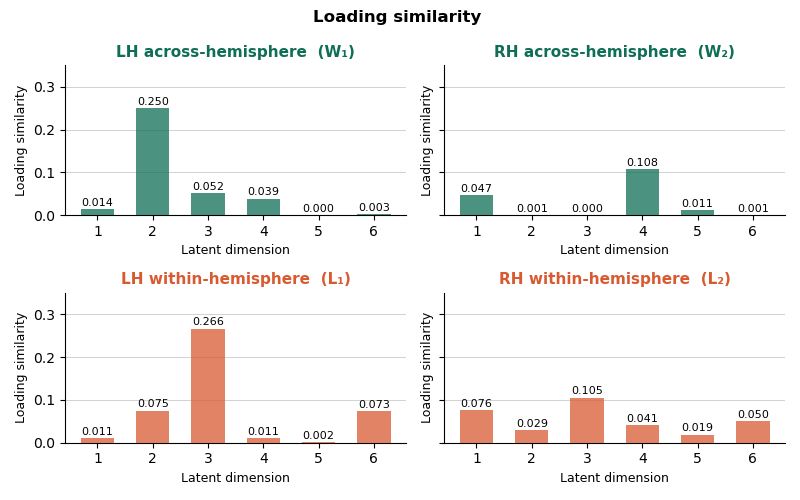

In [82]:
loading_similarity = metrics['load_sim'] 

teal   = '#0F6E56'   # across-hemisphere (W)
coral  = '#D85A30'   # within-hemisphere (L)

panels = [
    ('ls_W_1', 'LH across-hemisphere  (W₁)',  teal),
    ('ls_W_2', 'RH across-hemisphere  (W₂)',  teal),
    ('ls_L_1', 'LH within-hemisphere  (L₁)',  coral),
    ('ls_L_2', 'RH within-hemisphere  (L₂)',  coral),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharey=True)
axes = axes.flatten()

for ax, (key, title, color) in zip(axes, panels):
    vals = loading_similarity[key]
    dims = np.arange(1, len(vals) + 1)

    bars = ax.bar(dims, vals, color=color, alpha=0.75, width=0.6, zorder=3)

    # value labels above each bar
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Latent dimension', fontsize=9)
    ax.set_ylabel('Loading similarity', fontsize=9)
    ax.set_xticks(dims)
    ax.set_ylim(0, 0.35)
    ax.axhline(0, color='#999', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linewidth=0.4, zorder=0)

fig.suptitle('Loading similarity ',fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


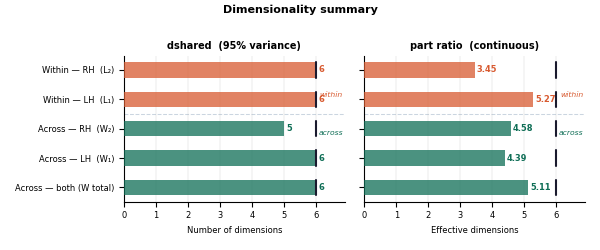

In [101]:

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

teal  = '#0F6E56'
coral = '#D85A30'

# ── pull values ───────────────────────────────────────────────────────────────
d  = model.params['d']
d1 = model.params['d1']
d2 = model.params['d2']

ds = metrics['dshared']
pr = metrics['part_ratio']

labels   = ['Across — both (W total)',
            'Across — LH  (W₁)',
            'Across — RH  (W₂)',
            'Within — LH  (L₁)',
            'Within — RH  (L₂)']

dshared_vals = [ds['dshared_W_total'], ds['dshared_W_1'], ds['dshared_W_2'],
                ds['dshared_L_1'],     ds['dshared_L_2']]

pr_vals      = [pr['pr_W_total'], pr['pr_W_1'], pr['pr_W_2'],
                pr['pr_L_1'],     pr['pr_L_2']]

budgets = [d, d, d, d1, d2]
colors  = [teal, teal, teal, coral, coral]

y      = np.arange(len(labels))
height = 0.52
xmax   = max(d, d1, d2) + 0.9

# ── figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
fig.subplots_adjust(wspace=0.06)

for ax, vals, fmt, title, xlabel in [
    (ax1, dshared_vals, lambda v: str(int(v)),  'dshared  (95% variance)',  'Number of dimensions'),
    (ax2, pr_vals,      lambda v: f'{v:.2f}',   'part ratio  (continuous)', 'Effective dimensions'),
]:
    ax.barh(y, vals, color=colors, alpha=0.75, height=height, zorder=3)

    for i, v in enumerate(vals):
        ax.text(v + 0.07, i, fmt(v), va='center', fontsize=6,
                fontweight='bold', color=colors[i])

    for i, budget in enumerate(budgets):
        ax.plot([budget, budget], [i - height / 2, i + height / 2],
                color='#1A1A2E', linewidth=1.5, zorder=5, solid_capstyle='round')

    ax.set_xlim(0, xmax)
    ax.set_title(title, fontsize=7, fontweight='bold', pad=5)
    ax.set_xlabel(xlabel, fontsize=6)
    ax.tick_params(axis='both', labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linewidth=0.3, alpha=0.6, zorder=0)

ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=6)

for ax in (ax1, ax2):
    ax.axhline(2.5, color='#CBD5E0', linewidth=0.75, linestyle='--', zorder=1)
    ax.text(xmax - 0.05, 3.15, 'within', ha='right', va='center',
            fontsize=5.5, color=coral, style='italic')
    ax.text(xmax - 0.05, 1.85, 'across', ha='right', va='center',
            fontsize=5.5, color=teal, style='italic')

legend_elements = [
    mpatches.Patch(color=teal,  alpha=0.75, label='Across-hemisphere (W)'),
    mpatches.Patch(color=coral, alpha=0.75, label='Within-hemisphere (L)'),
    Line2D([0], [0], color='#1A1A2E', linewidth=1.5,
           label=f'CV-selected dims (d={d}, d1={d1}, d2={d2})'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=6,
           bbox_to_anchor=(0.5, -0.12), frameon=False)

fig.suptitle(f'Dimensionality summary', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
metrics['rho'] 

array([0.77855314, 0.76945668, 0.71309547, 0.65592148, 0.61074819,
       0.60029102])

In [31]:
cv_results['final_LL']

-225546.44825578167

In [22]:
model.params['cv_rho']

array([0.68511471, 0.73430407, 0.66525662, 0.47123724, 0.58848336,
       0.5059766 ])

In [20]:
metrics['load_sim']

{'ls_W_1': array([1.35528964e-02, 2.50399545e-01, 5.21441552e-02, 3.88729928e-02,
        3.12603096e-05, 2.61467044e-03]),
 'ls_W_2': array([4.66638651e-02, 5.73082865e-04, 4.66318174e-07, 1.08092038e-01,
        1.14744442e-02, 5.44433281e-04]),
 'ls_L_1': array([0.01138339, 0.07473875, 0.2664885 , 0.01050927, 0.00215821,
        0.07335447]),
 'ls_L_2': array([0.07598961, 0.02861764, 0.10546733, 0.04072594, 0.01874508,
        0.04963416])}

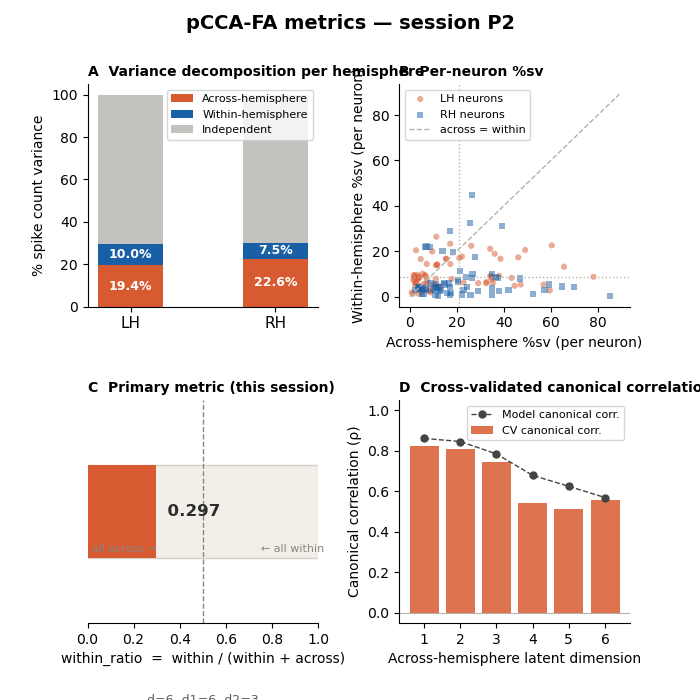

In [ ]:
# fig = plot_session_metrics(metrics_old, summary_old, session_id=session_id)

In [ ]:
# Superseded by the windows loop above.
# fig = plot_session_metrics(metrics, summary, session_id=session_id)

In [130]:
# # Call this on your preprocessed matrices
# z, LL = model.estep(bundle['lh'], bundle['rh'])

# z['z_mu']    # (T, d)   ← across-hemisphere latent variables, one value per trial
# z['zx1_mu']  # (T, d1)  ← within-LH latent variables per trial
# z['zx2_mu']  # (T, d2)  ← within-RH latent variables per trial
# # z_cov, zx1_cov, zx2_cov also available — posterior uncertainty per dimension

In [131]:
# metrics['psv'].keys()
# dict_keys(['psv_W_1', 'psv_W_2', 'psv_L_1', 'psv_L_2', 'avg_psv_W_1', 'avg_psv_W_2', 'avg_psv_L_1', 'avg_psv_L_2', 'ind_var_x1', 'ind_var_x2', 'avg_psv_W_total', 'avg_psv_L_total'])

In [132]:
summary

{'session_id': 'P3',
 'avg_psv_W': 25.397028376437735,
 'avg_psv_L': 3.4440049995142363,
 'within_ratio': 0.1194133703401173,
 'avg_psv_W_lh': 27.636876842914926,
 'avg_psv_L_lh': 3.1061839883069355,
 'avg_psv_W_rh': 23.26383936074517,
 'avg_psv_L_rh': 3.7657392959021427,
 'within_ratio_lh': 0.10103691383755696,
 'within_ratio_rh': 0.13931920078140192,
 'd': 6,
 'd1': 1,
 'd2': 1}

In [133]:
# # ── putting it together for one session ───────────────────────────────────────

# def run_session(bundle, session_id=None, d_max=6, n_folds=10, rand_seed=42):
#     """
#     Full Steps 4+5 for one session. Call this per animal.

#     Returns model, cv_results, metrics, summary.
#     """
#     model, cv_results = fit_session_pcca(
#         bundle, d_max=d_max, n_folds=n_folds, rand_seed=rand_seed
#     )
#     metrics, summary = extract_session_metrics(model, session_id=session_id)

#     print(f"\n── Session {session_id} ──────────────────────")
#     print(f"  across %sv : {summary['avg_psv_W']:.2f}%")
#     print(f"  within %sv : {summary['avg_psv_L']:.2f}%")
#     print(f"  within_ratio (primary): {summary['within_ratio']:.4f}")

#     return model, cv_results, metrics, summary

# from scipy.stats import mannwhitneyu
# import pandas as pd

# # collect per-session summaries into a dataframe
# # run_session() once per animal, label each with training group
# records = []
# for session_id, bundle, group in session_list:   # group = 'unilateral' or 'bilateral'
#     _, _, _, summary = run_session(bundle, session_id=session_id)
#     summary['group'] = group
#     records.append(summary)

# df = pd.DataFrame(records)

# # group-level comparison on the primary metric
# uni = df.loc[df['group'] == 'unilateral', 'within_ratio']
# bil = df.loc[df['group'] == 'bilateral',  'within_ratio']

# stat, p = mannwhitneyu(uni, bil, alternative='greater')  # H1: unilateral > bilateral

# print(f"\nMann-Whitney U:  U={stat:.1f},  p={p:.4f}")
# print(f"Unilateral within_ratio:  mean={uni.mean():.4f}, n={len(uni)}")
# print(f"Bilateral  within_ratio:  mean={bil.mean():.4f}, n={len(bil)}")